# ML Final Project — Mice Protein Expression (UCI)

Group members:
- Rami Abou Fakhr (ID: 2185019)
- Amir H. Q. Selakjan (ID: 2183917)
- Alison Mae Worth (ID: 2183914)

Group: 8
Dataset: Mice Protein Expression — UCI (ID 342)
Task: Binary classification — control vs trisomic genotype

---

## Section 0 — Setup

In [48]:
# Section 0 - Setup

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    fetch_ucirepo = None
    print("ucimlrepo not installed. Run: pip install ucimlrepo")

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

In [49]:
# If ucimlrepo isn't installed in this kernel yet, install it then import.
# '%pip install ucimlrepo'

from ucimlrepo import fetch_ucirepo

---

## Section 1 — Biological question

### Background

Down syndrome is caused by trisomy of chromosome 21, however the molecular mechanisms involved downstream are not fully understood.  To study the molecular basis and effect of a disease, many scientists utilize in vivo mouse models.   The Ts65Dn model, which carries a partial trisomy of mouse chromosome 16, is one of the most widely used mouse models for studying down syndrome.

This dataset was collected by Higuera et al. (2015) and contains protein expression levels measured in the cerebral cortex of control and trisomic mice that were either stimulated to learn (via context fear conditioning) or left unstimulated, and treated with memantine or saline.

### Biological question

> Can we classify mice as control or trisomic based solely on their cortical protein expression profile?

### Structured answer

```
Biological question:
    Can we predict whether a mouse has a trisomic (Ts65Dn) or control genotype
    from the expression levels of 77 proteins measured in the cerebral cortex?

Input data:
    Protein expression levels (77 proteins) measured from mouse cortex tissue.
    Each value is a normalized fluorescence intensity from antibody-based
    protein quantification.

Target variable:
    Genotype — binary: "Control" (normal diploid) vs "Ts65Dn" (trisomic).

One row represents:
    A single mouse cortex sample (one measurement session per mouse).

One column represents:
    The normalized expression level of one specific protein across all mice.

Biological relevance:
    Identifying which proteins differ between genotypes can reveal molecular
    pathways disrupted in trisomy 21. This is relevant both for understanding
    Down syndrome mechanisms and for identifying potential therapeutic targets.
    A classifier that separates genotypes purely from protein levels confirms
    that the proteomic signature of trisomy is detectable at the individual
    sample level, not only at the group mean level.
```

---

## Section 2 — Load the dataset

In [50]:
# Section 2 - Load the dataset

if fetch_ucirepo is None:
    raise ImportError("ucimlrepo is required. Install with: pip install ucimlrepo")

mice = fetch_ucirepo(id=342)

mice_features = mice.data.features.copy()
mice_targets  = mice.data.targets.copy()
mice_original = mice.data.original.copy()

print("Feature columns (first 10):", mice_features.columns.tolist()[:10], "...")
print("Target columns:",             mice_targets.columns.tolist())
print("Original columns (first 15):",mice_original.columns.tolist()[:15], "...")
print()
print("Dataset shape (features):", mice_features.shape)

mice_original.head()

Feature columns (first 10): ['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N'] ...
Target columns: ['class']
Original columns (first 15): ['MouseID', 'DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N'] ...

Dataset shape (features): (1080, 80)


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


### Reflection points for Section 2

In [51]:
len(mice_original["MouseID"].unique())

1080

In [52]:
# Point 2.1 - Number of samples and variables
n_samples, n_vars = mice_features.shape
print(f"Number of samples:   {n_samples}")
print(f"Number of unique samples: {len(mice_original["MouseID"].unique())}") # to see if multiple samples come from the same mouse
print(f"Number of variables: {n_vars}")

Number of samples:   1080
Number of unique samples: 1080
Number of variables: 80


Point 2.1 — Number of samples and variables: The dataset has 1,080 unique samples (each sample from a mouse). `mice.data.features` returns 80 columns: 77 numeric protein expression features plus three categorical metadata columns (`Genotype`, `Treatment`, `Behavior`). The 77 protein features are the actual model inputs and are isolated in Section 4 with `select_dtypes(include="number")`.

In [53]:
# Point 2.2 - Column roles
print("=== Columns in mice_original but NOT in mice.data.features ===")
metadata_cols = [c for c in mice_original.columns if c not in mice_features.columns]
print(metadata_cols)
print()
print("=== Columns inside mice.data.features ===")
print(mice_features.columns.tolist())
print()
print("=== Target (Genotype, taken from mice_original) ===")
print(mice_original["Genotype"].value_counts())

=== Columns in mice_original but NOT in mice.data.features ===
['MouseID', 'class']

=== Columns inside mice.data.features ===
['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N', 'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N', 'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N', 'Bcatenin_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N', 'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N', 'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N', 'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N', 'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N', 'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N', 'SHH_N', 'BAD_N', 'BCL2_N', 'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N', 'CaNA_N', 'Genotype', 'Treatment', 'Behavior']

=== Target (Gen

Point 2.2 — Column roles:
- Columns in `mice_original` but not in `mice.data.features`: only `MouseID` and `class`.
- Input features: 77 columns of normalized protein expression levels (numeric `float64`). Note that `mice.data.features` also bundles three categorical columns — `Genotype`, `Treatment`, `Behavior` — which describe experimental conditions, not protein measurements.
- Target: The repository's designated target (`mice.data.targets`) is `class`, an 8-category label. For this binary project the target is `Genotype` — two values, `Control` and `Ts65Dn` — taken from `mice_original`.

In [54]:
mice_features.shape

(1080, 80)

In [55]:
# Point 2.3 - Missing values
missing_per_col = mice_features.isnull().sum()

print(f"Total number of columns with missing values: {len(missing_per_col[missing_per_col > 0].sort_values(ascending=False))}/{mice_features.shape[1]}")

print()
total_missing = missing_per_col.sum()
total_cells   = mice_features.shape[0] * mice_features.shape[1]
print(f"Total missing cells: {total_missing} / {total_cells} ({100*total_missing/total_cells:.2f}%)")

Total number of columns with missing values: 49/80

Total missing cells: 1396 / 86400 (1.62%)


Point 2.3 — Missing values: Missing values affect 49 of the feature columns, totalling about 1.6% of all feature cells. No column is completely empty, but the missingness is uneven — most columns lose only a few values, while the most affected (`BCL2_N`) is missing about 26% of its entries. The plan is to impute with the column median (not mean), because protein expression data can be skewed by outliers and median imputation is more robust in that case. This is done in Section 6 (preprocessing) after the train/test split to avoid data leakage.

In [56]:
# Point 2.4 - Data types
print("Data types in the features object:")
print(mice_features.dtypes.value_counts())
print()
print("Non-numeric columns (if any):")
non_numeric = mice_features.select_dtypes(exclude="number").columns.tolist()
print(non_numeric if non_numeric else "None")

Data types in the features object:
float64    77
object      3
Name: count, dtype: int64

Non-numeric columns (if any):
['Genotype', 'Treatment', 'Behavior']


Point 2.4 — Data types: `mice.data.features` contains 77 numeric (`float64`) protein columns and 3 object (text) columns — `Genotype`, `Treatment`, `Behavior`. So `select_dtypes(exclude="number")` returns those three categorical columns, not `None`. They are experimental-condition labels rather than measurements; Section 4 keeps only the 77 numeric protein columns as `X`. No unexpected types are present among the protein features.

---

## Section 3 — Identify the ML task

In [57]:
# Section 3 - Identify the ML task

print("Target variable: Genotype")
print("Unique values:", mice_original["Genotype"].unique())
print("Value counts:")
print(mice_original["Genotype"].value_counts())
print()
print("Number of unique classes:", mice_original["Genotype"].nunique())
print("Target dtype:", mice_original["Genotype"].dtype)

Target variable: Genotype
Unique values: ['Control' 'Ts65Dn']
Value counts:
Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

Number of unique classes: 2
Target dtype: object


```
Target type:       Categorical, binary (two classes)

Problem type:      Binary classification
                   The target is "Control" vs "Ts65Dn" — two discrete categories.
                   There is no natural ordering, so regression is not appropriate.

Compatible models: Logistic Regression, Decision Tree, Random Forest,
                   K-Nearest Neighbours, Support Vector Classifier, Neural Network

Models that are not appropriate and why:
  - Linear Regression: the target is categorical, not continuous.
    Predicting a real number makes no biological sense here.
  - Regression trees (for continuous targets): same reason.
  - Unsupervised methods (PCA, k-means): we have labels, so supervised
    classification is the more appropriate framework.
```

---

## Section 4 — Define X and y

In [58]:
# Section 4 - Define X and y

# X = the protein columns (only the numeric ones) as a dataframe
X = mice_features.select_dtypes(include="number").copy()

# y = genotype turned into numbers with LabelEncoder (Control=0, Ts65Dn=1)
le = LabelEncoder()
y = pd.Series(le.fit_transform(mice_original["Genotype"]), name="Genotype_encoded")

print("Encoder classes:", le.classes_)   # order matches 0, 1
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Counts in y:")
print(y.value_counts())

Encoder classes: ['Control' 'Ts65Dn']
X shape: (1080, 77)
y shape: (1080,)

Counts in y:
Genotype_encoded
0    570
1    510
Name: count, dtype: int64


### Reflection points for Section 4

Point 4.1 — Shape of X:
`X` has shape (1080, 77).
- Dimension 0 (rows = 1080): each row is one mouse cortex sample.
- Dimension 1 (columns = 77): each column is the normalized expression level of one protein.

Point 4.2 — Shape of y:
`y` has shape (1080,). Each element is a binary label: `0` for control mice, `1` for trisomic (Ts65Dn) mice.

Point 4.3 — Transpose:
No transposition was needed. The UCI repository already provides `mice.data.features` in ML-standard orientation (rows = samples, columns = proteins). This is different from some gene expression formats (e.g., GEO matrices) where genes are rows and samples are columns and a transpose is required.

Point 4.4 — Alternative ML tasks from the same dataset:
The dataset contains additional columns that could be used as alternative targets:
- `Treatment` (memantine vs saline) → different binary classification question
- `Behavior` (context-shock vs shock-only stimulation) → another binary classification
- `class` → an 8-class multiclass problem (combinations of genotype × treatment × behavior)

The choice of target changes the biological question entirely. Using `class` instead of `Genotype` would ask whether we can distinguish all experimental conditions at once, which is harder and less interpretable. We chose `Genotype` because it is the most direct proxy for the Down syndrome model phenotype.

---

## Section 5 — Dataset audit

In [59]:
# Section 5 - Dataset audit

# 5a: size relative to features
print("=== Size and dimensionality ===")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Ratio samples/features: {X.shape[0] / X.shape[1]:.1f}")

=== Size and dimensionality ===
Samples:  1080
Features: 77
Ratio samples/features: 14.0


=== Class balance ===
Genotype_encoded
0    570
1    510
Name: count, dtype: int64

Class 0 (Control):  570 samples (52.8%)
Class 1 (Ts65Dn):   510 samples (47.2%)


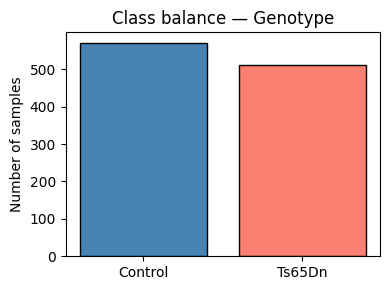

In [60]:
# 5b: class balance
print("=== Class balance ===")
counts = y.value_counts()
print(counts)
print()
print(f"Class 0 (Control):  {counts[0]} samples ({100*counts[0]/len(y):.1f}%)")
print(f"Class 1 (Ts65Dn):   {counts[1]} samples ({100*counts[1]/len(y):.1f}%)")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["Control", "Ts65Dn"], [counts[0], counts[1]], color=["steelblue", "salmon"], edgecolor="black")
ax.set_ylabel("Number of samples")
ax.set_title("Class balance — Genotype")
plt.tight_layout()
plt.show()

In [61]:
# 5c: missing values recap
print("=== Missing values (recap) ===")
missing_col = X.isnull().sum()
print(f"Columns with at least one missing value: {(missing_col > 0).sum()} / {X.shape[1]}")
print()
print("Top columns by missingness:")
print(missing_col[missing_col > 0].sort_values(ascending=False).head(10))

=== Missing values (recap) ===
Columns with at least one missing value: 49 / 77

Top columns by missingness:
BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
ITSN1_N         3
dtype: int64


In [62]:
# 5d: check the value ranges of the features
print("=== Feature value ranges ===")
print("Smallest value overall:", round(X.min().min(), 4))
print("Biggest value overall: ", round(X.max().max(), 4))
print("Average of column means:", round(X.mean().mean(), 4))
print("Smallest column std:", round(X.std().min(), 4))
print("Biggest column std: ", round(X.std().max(), 4))

=== Feature value ranges ===
Smallest value overall: -0.062
Biggest value overall:  8.4826
Average of column means: 0.6719
Smallest column std: 0.0132
Biggest column std:  1.2952


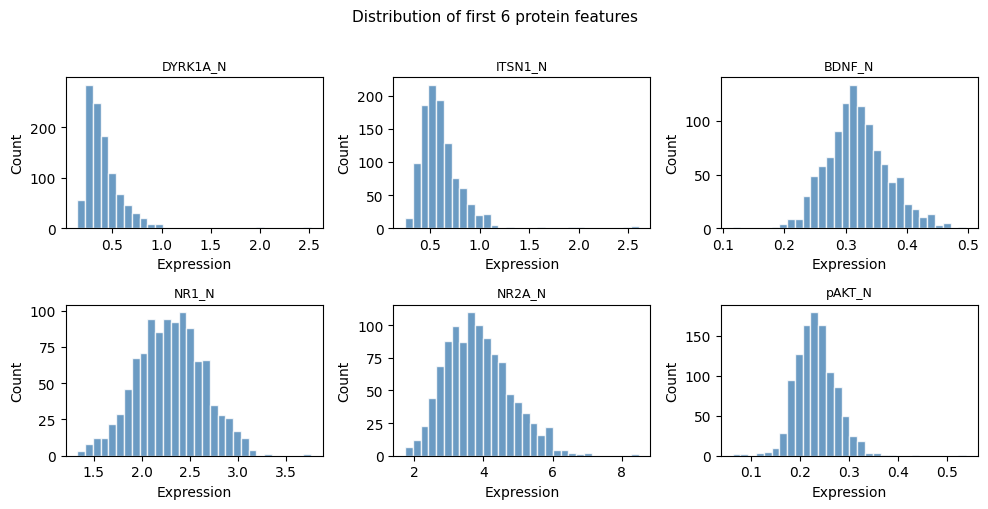

In [63]:
# 5e: distribution of a few proteins to check for outliers / skew
sample_proteins = X.columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, col in enumerate(sample_proteins):
    axes[i].hist(X[col].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Expression")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of first 6 protein features", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

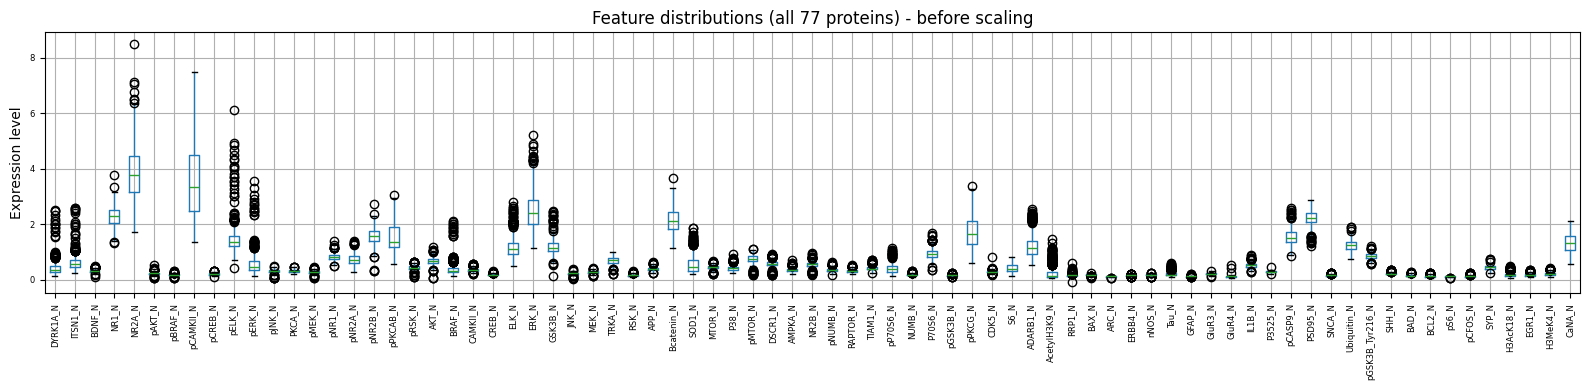

In [64]:
# 5f: boxplot of all the proteins to see the different scales
plt.figure(figsize=(16, 4))
X.boxplot(rot=90, fontsize=6)
plt.title("Feature distributions (all 77 proteins) - before scaling")
plt.ylabel("Expression level")
plt.tight_layout()
plt.show()

### Reflection points for Section 5

Point 5.1 — Dataset size relative to features:
1,080 samples with 77 features gives a ratio of ~14:1. This is a reasonable medium-sized dataset. It is large enough for ensemble methods like Random Forest, and small enough that a large neural network could overfit easily. Logistic regression is also appropriate at this scale.

Point 5.2 — Class balance:
The dataset can be considered barely imbalanced: 570 Control (52.8%) and 510 Ts65Dn (47.2%). Accuracy is still a reasonable metric, but the relevant no-information baseline is a majority-class classifier scoring ~52.8%, not 50%. The imbalance is small enough that no resampling or class-weight adjustment is required; stratified splitting preserves the ratio across folds.

Point 5.3 — Feature scaling:
The protein expression values are normalized intensities that mostly sit below \~1 (the average feature mean is \~0.67), but individual values range from slightly below 0 (about -0.06) up to \~8.5, and the per-feature standard deviations vary widely (\~0.01 to \~1.3). Because the scales and spreads differ across proteins, `StandardScaler` should be applied for:
- Logistic Regression (gradient-descent-based, sensitive to scale)
- KNN (distance-based, very sensitive to scale)

Random Forest and Decision Tree are scale-invariant (split on individual feature values), so scaling is not required for those — but it does not hurt to apply it uniformly for consistency.

Point 5.4 — Main risks:
- Data leakage: The features object includes the categorical columns `Genotype`, `Treatment`, and `Behavior`, which are correlated with the target by experimental design. If any of these leaked into X, the classifier would be partially predicting the experimental condition rather than learning the proteomic signature. This is avoided by selecting only the numeric protein columns as X.
- Mild multicollinearity: Some proteins in the same signaling pathway are likely correlated. This can inflate variance in logistic regression coefficients but does not prevent classification.
- Sparse missing values: handled by imputation (not deletion).

---

## Section 6 — Pre-processing and Baseline Modeling

In [65]:
# Section 6 - Pre-processing
# Split first, then impute and scale using only the training data (no leakage)

# first split off the test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
                                                X, y, test_size=0.20, random_state=42, stratify=y)

# then split the rest into train and validation
# 0.25 of the 80% = 20% of everything, so it ends up 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
                                        X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 648
Val size:   216
Test size:  216


In [66]:
# fill in missing values with the median of each column (fit on train only)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# scale the features to mean 0 / std 1 (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

Pre-processing rationale:
- Imputer fitted on train only. The validation and test medians are not known at training time, so they must be estimated from training data only. Using the full dataset's median would leak information about the test set into the imputation.
- Scaler fitted on train only. Same reason — the scaler's mean and standard deviation come only from the training samples.
- Stratified splits. Because the dataset is only mildly imbalanced (about 53/47), stratified splitting keeps that same class ratio in each split.

### Baseline model (Dummy classifier)

In [67]:
# Baseline: DummyClassifier (most_frequent)

# little helper so we don't have to retype the metrics for every model
def show_scores(y_true, y_pred):
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:   ", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1 score: ", round(f1_score(y_true, y_pred, zero_division=0), 4))

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_sc, y_train)
y_val_dummy = dummy.predict(X_val_sc)

print("=== Baseline: DummyClassifier (most frequent class) ===")
show_scores(y_val, y_val_dummy)
print()
print("The baseline always predicts the majority class (Control).")
print("Any useful model needs to score clearly above this.")

=== Baseline: DummyClassifier (most frequent class) ===
Accuracy:  0.5278
Precision: 0.0
Recall:    0.0
F1 score:  0.0

The baseline always predicts the majority class (Control).
Any useful model needs to score clearly above this.


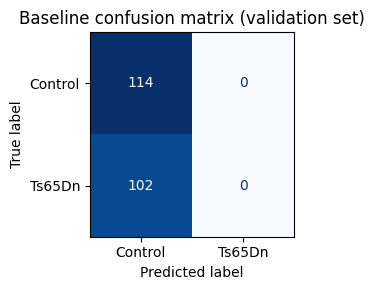

In [68]:
# Confusion matrix for baseline
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_dummy,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Baseline confusion matrix (validation set)")
plt.tight_layout()
plt.show()

### Reflection points for Section 6 (Baseline)

Point 6.1 — Choice of baseline:
The `DummyClassifier` with `strategy='most_frequent'` was chosen. It always predicts the majority class (Control), which achieves about 52.8% accuracy on this dataset.

Point 6.2 — Why this baseline is appropriate:
The most-frequent baseline formalizes the "no-information" performance level — the score obtained by ignoring the protein data entirely and always guessing the larger class. Any model that genuinely learns from protein expression must score well above this ~52.8%.

Point 6.3 — Baseline performance on validation:
As expected, accuracy is ~53%. Because the classifier only ever predicts the majority class, precision, recall, and F1 for the minority class are zero (or undefined) — `zero_division=0` handles this gracefully.

Point 6.4 — Threshold for a useful model:
A useful model must exceed the ~52.8% majority-class rate by a meaningful margin (say, >65-70% accuracy) on the validation set before it is worth interpreting biologically. Given that genotype differences in protein expression are well-documented in the literature (Higuera et al. 2015 reported very clear separation), we expect candidate models to achieve considerably higher accuracy than the baseline.

---

## Section 7 — Candidate models and justification

```
Baseline model:
    DummyClassifier (majority class predictor)
    Expected accuracy: ~52.8% (always predicts the majority class, Control)

Candidate model 1: Logistic Regression
Why this model:
    Standard first choice for binary classification. Interpretable
    coefficients allow identifying which proteins drive the decision.
    Works well when the class boundary is approximately linear in feature
    space, which is plausible here because protein expression differences
    between genotypes may be additive.
Expected advantage:
    Interpretable, fast, well-regularized with L2 penalty (Ridge).
    Coefficients can be mapped back to biological protein names.
Expected risk:
    With 77 features and 648 training samples the model may
    underfit if the relationship is nonlinear, or overfit if
    many correlated proteins are included. Regularization (C parameter)
    must be tuned.

Candidate model 2: Random Forest Classifier
Why this model:
    Handles nonlinear interactions and feature correlations well.
    Provides feature importances that are biologically interpretable.
    Does not require feature scaling. Robust to a small number of
    irrelevant features.
Expected advantage:
    Higher accuracy than logistic regression if the genotype boundary
    is nonlinear in protein space. Less sensitive to multicollinearity.
Expected risk:
    Black-box relative to logistic regression. Feature importances
    from Random Forest can be biased toward high-cardinality features
    (less relevant here since all features are continuous).
    May overfit on a small training set if trees are too deep.

Candidate model 3 (optional): K-Nearest Neighbours
Why this model:
    Nonparametric, makes no assumptions about the form of the decision
    boundary. Useful as a comparison point to check whether the
    classification problem has a local geometric structure.
Expected advantage:
    Simple, no training phase. Good for checking if nearby samples
    in protein space share genotype.
Expected risk:
    Suffers in higher dimensions (77 features is moderately high).
    Very sensitive to scaling and to irrelevant features. Slow at
    inference on large datasets.
```

### Reflection points for Section 7

Point 7.1 — Feature scaling requirements:

| Model | Scaling required? | Reason |
|---|---|---|
| Logistic Regression | Yes | Uses gradient-based optimisation; features on different scales cause uneven updates and slow convergence |
| Random Forest | No | Splits on individual feature thresholds; scale does not affect split quality |
| KNN | Yes | Uses Euclidean distance; large-scale features dominate distance calculations |

Since all three models will be compared, I apply `StandardScaler` uniformly to all.

Point 7.2 — Key hyperparameters per model:

| Model | Key hyperparameter | Effect |
|---|---|---|
| Logistic Regression | `C` (inverse of regularisation strength) | Low C = strong regularisation = underfitting risk; High C = weak regularisation = overfitting risk |
| Random Forest | `n_estimators`, `max_depth` | More trees = lower variance; deeper trees = higher variance |
| KNN | `n_neighbors` (k) | Small k = complex boundary; large k = smoother boundary |

Point 7.3 — Ranking from most to least interpretable:
1. Logistic Regression — signed coefficients per feature, directly shows which proteins push toward one class
2. Decision Tree (if used) — explicit split rules
3. Random Forest — feature importances available, but the ensemble as a whole is not directly readable
4. KNN — no parameters to inspect; the "model" is just the training data

Point 7.4 — Most likely to overfit:
KNN with small k is the most prone to overfitting, because it will memorize local training noise. Random Forest with very deep trees can also overfit, but the ensemble averaging mitigates this. Logistic Regression with strong regularisation (small C) is the least likely to overfit.

## Section 8 — Train, validation, and test strategy

In [69]:
# The splits
print("Shapes of the final splits:")
print("X_train:", X_train_sc.shape)
print("X_val:  ", X_val_sc.shape)
print("X_test: ", X_test_sc.shape)
print()

# Class balance
for name, ysplit in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    n0 = (ysplit == 0).sum()
    n1 = (ysplit == 1).sum()
    print(name, "-> Control:", n0, " Ts65Dn:", n1)

Shapes of the final splits:
X_train: (648, 77)
X_val:   (216, 77)
X_test:  (216, 77)

Train -> Control: 342  Ts65Dn: 306
Val -> Control: 114  Ts65Dn: 102
Test -> Control: 114  Ts65Dn: 102


### Reflection points for Section 8
Point 8.1 — Splitting the data:
The data was already split when the baseline model was fitted (Section 6)

Point 8.2 — Number of samples in each split:
With a total of 1080 samples, 648 of them (60%) went into training, with the remaining samples being split evenly between validation (216) and test (216) sets (20% & 20%).

Point 8.3 — Class Balance:
With the help of `stratify=y`, the class balance across all splits is preserved (~52% for control and ~47% for trisomic samples).

Point 8.4 — Why the test set is not a model evaluation metric:
The test set should be, as the name implies, the "test" for the model. One does not evaluate how well they will do in an exam by taking a look at the exam beforehand.
The same goes with building a model; the model is trained using a subset of samples, and the validation subset of samples is used to validate whether the model trained well or not, whether other models trained better, and/or whether re-training with different hyperparameters is needed.
Only after choosing the assumed best model does one evaluate its performance on completely unseen data (test set).

## Section 9 — Choosing evaluation metrics

```text
Primary metric:
- Accuracy. Since the data is mostly balanced, the accuracy score will not inflate the model's performance, making it a reliable evlaluation metric for this project.

Secondary metrics:
- F1 score. In case accuracy still ends up being a bit misleading, the F1 score can be a reliable metric that minimizes ambiguity since it is the harmonic mean of precision and recall that is not affected by class imbalance:

                                            (Precision*Recall) / (Precision+Recall)


- ConfusionMatrix. It it always a useful metric that provides visual intuition on how well the model performed in classifying the positives (`Ts65Dn`) and the negatives (`Control`)

Which error is more biologically problematic, false positives or false negatives?
- In the context of classifying normal mice from trisomic ones, having a normal mouse produce a trisomic signal (False positive) could potentially be more problematic since the model evaluates the protein expression profile as one similar to a trisomic individual, making it harder to detect this faulty classification.
On the other hand, a trisomic mouse producing a normal signal (False negative) would allow more room for doubt since, at the end of the day, the test is being conducted on a limited set of 77 proteins, and there can be many more ways to disprove the "normal" signal.
```

In [70]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

We can run this function on the fitted baseline (dummy) model from before:

In [71]:
classification_metrics(y_val, y_val_dummy)

{'accuracy': 0.5277777777777778,
 'F1': 0.0,
 'confusion_matrix': array([[114,   0],
        [102,   0]])}

The baseline always predicts the majority class (Control).<br>
Any useful model needs to score clearly above this.

## Section 10 — Training and comparing models

#### Logistic Regression
The first model we will use is the logistic regression one, which calculates:
$$h_{\theta}(X)=\frac{1}{1+e^{-\theta^T.X}}$$
where $X$ is the vector of values for every feature, $\theta^T$ is the transposed vector of parameters (weights) for every feature, and $h_{\theta}(X)$ is the probability of being in the positive class, for any given input sample.
This probability is then mapped to either class 1 (trisomic) or class 0 (control) by applying a decision threshold (0.5) to the linear score $\theta^T.X$, resulting in a linear decision boundary in the feature space.<br>
It is a linear decision boundary because the decision threshold relies on $\theta^T.X=0$, the combination of the parameters in a linear fashion. When the equation is true, then $h_{\theta}(X)=0.5$, the exact probability that separates between the two classes.

In [72]:
# Choosing the most suitable hyperparameter 'C':
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        penalty='l2',
        C=C
    )

    model.fit(X_train_sc, y_train) # using the scaled data

    val_acc = model.score(X_val_sc, y_val)
    print(f"C={C}: {val_acc:.4f}")

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:

C=0.001: 0.6574
C=0.01: 0.8704
C=0.1: 0.9630
C=1: 0.9583
C=10: 0.9444
C=100: 0.9583


It is clear that `C=0.1` is optimal in this case, which will be chosen for tuning the final model:

Training Accuracy: 0.970679012345679

=== Logistic Regression ===

The accuracy on the validation set: 0.9629629629629629

The F1 score on the validation set: 0.9603960396039604



C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


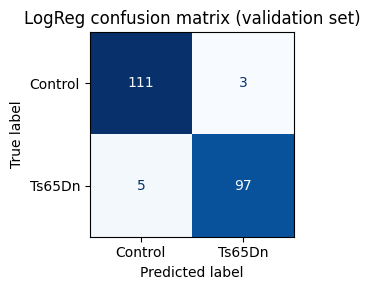

In [73]:
# Logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000, penalty='l2', C=0.1)

# fitting the model on the scaled training set
log_reg.fit(X_train_sc, y_train)

# training performance
train_pred = log_reg.predict(X_train_sc)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print()

# Predictions on validation set
log_reg_y_pred = log_reg.predict(X_val_sc)

report = classification_metrics(y_val, log_reg_y_pred)
print("=== Logistic Regression ===")
print()
print("The accuracy on the validation set:",report["accuracy"])
print()
print("The F1 score on the validation set:",report["F1"])
print()

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, log_reg_y_pred,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("LogReg confusion matrix (validation set)")
plt.tight_layout()
plt.show()

We can see how both the 'accuracy' and 'F1' metrics report similar scores of ~0.96, reassuring the promising performance from the model.<br>
Also, out of 100 classifications as positive (trisomic), only 3 were reported as false negative (normal), making the model generally robust to unseen data.


We will also build a Random Forest model to explore the performance from another perspective.

#### Random Forest
To keep it brief, a Random Forest is an ensemble of decision trees. Each tree is trained on a different random subset of the training data and considers only a random subset of features (at each split). This introduces diversity among the trees and reduces overfitting.

For a classification problem, each tree produces a class prediction:
$$T_b \in \{0,1\}$$

where $T_b$ is the prediction of the b-th tree.

The estimated probability of belonging to class 1 can be written as:
$$P(y=1∣X)= \frac{1}{B}\sum_{b=1}^BT_b(X)$$


and a threshold of 0.5 is then applied to determine the final class.

In [74]:
# choosing the best hyperparameters
for n_est in [20,50,80,100,150,200]:
    for d in [3, 5, 10, 15, 20, 30, 50]:
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=d,
            random_state=42
        )
        
        rf.fit(X_train, y_train)  # using unscaled features
        
        val_acc = rf.score(X_val, y_val)
        print(f"n_est={n_est} & d={d}: {val_acc:.4f}")

n_est=20 & d=3: 0.8148
n_est=20 & d=5: 0.8981
n_est=20 & d=10: 0.9630
n_est=20 & d=15: 0.9491
n_est=20 & d=20: 0.9491
n_est=20 & d=30: 0.9491
n_est=20 & d=50: 0.9491
n_est=50 & d=3: 0.8333
n_est=50 & d=5: 0.9074
n_est=50 & d=10: 0.9769
n_est=50 & d=15: 0.9630
n_est=50 & d=20: 0.9676
n_est=50 & d=30: 0.9676
n_est=50 & d=50: 0.9676
n_est=80 & d=3: 0.8241
n_est=80 & d=5: 0.9120
n_est=80 & d=10: 0.9815
n_est=80 & d=15: 0.9722
n_est=80 & d=20: 0.9722
n_est=80 & d=30: 0.9722
n_est=80 & d=50: 0.9722
n_est=100 & d=3: 0.8333
n_est=100 & d=5: 0.9120
n_est=100 & d=10: 0.9815
n_est=100 & d=15: 0.9630
n_est=100 & d=20: 0.9630
n_est=100 & d=30: 0.9630
n_est=100 & d=50: 0.9630
n_est=150 & d=3: 0.8472
n_est=150 & d=5: 0.9074
n_est=150 & d=10: 0.9676
n_est=150 & d=15: 0.9676
n_est=150 & d=20: 0.9676
n_est=150 & d=30: 0.9676
n_est=150 & d=50: 0.9676
n_est=200 & d=3: 0.8472
n_est=200 & d=5: 0.9213
n_est=200 & d=10: 0.9722
n_est=200 & d=15: 0.9676
n_est=200 & d=20: 0.9676
n_est=200 & d=30: 0.9676
n_est=20

Multiple candidates seem optimal, but `n_estimators=80` and `depth=20` will be chosen to avoid overfitting while maintaining the high score.

Training Accuracy: 1.0

=== Random Forest ===

The accuracy on the validation set: 0.9722222222222222

The F1 score on the validation set: 0.97



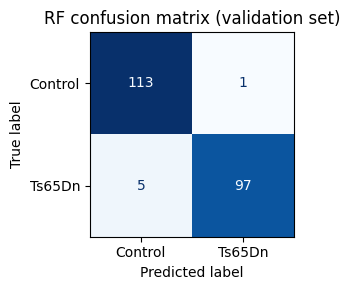

In [75]:
# building the model
rf = RandomForestClassifier(
            n_estimators=80,
            max_depth=20,
            random_state=42
        )

# fitting the model on the unscaled training set
rf.fit(X_train, y_train)

# training performance
train_pred = rf.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print()

# Predictions on validation set
rf_y_pred = rf.predict(X_val)

report = classification_metrics(y_val, rf_y_pred)
print("=== Random Forest ===")
print()
print("The accuracy on the validation set:",report["accuracy"])
print()
print("The F1 score on the validation set:",report["F1"])
print()

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, rf_y_pred,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("RF confusion matrix (validation set)")
plt.tight_layout()
plt.show()

A similar report profile was established, with 0.96 accuracy and F1-score on the validation set, yielding another potential "best model" for using on the test set.<br>
The confusion matrix only reported a single False Negative, which is very promising for future assessment.

Lastly, we will run the non-parametric KNN algorithm to build the model and evaluate how well the samples are organized in the feature space.

#### KNN
This algorithm does not work by learning a set of parameters during training. Instead, it stores the training samples and classifies new observations according to the classes of their nearest neighbors in the feature space.

For a new sample $X$, the distance to all training samples is calculated using the Euclidean distance:
$$d(X_i,X_j)=\sqrt{\sum_{k=1}^P(X_{ik}-X_{jk})^2}$$

and then selects the K-closest training samples and assigns the class that appears most frequently among them.

In [76]:
# choosing the best k
for k in [1, 3, 5, 7, 9, 11, 15, 21, 25, 31]:
    knn = KNeighborsClassifier(
        n_neighbors=k
    )
    
    knn.fit(X_train_sc, y_train) # scaled data
    val_acc = knn.score(X_val_sc, y_val)
    print(f"k={k}: {val_acc:.4f}")
    

k=1: 0.9861
k=3: 0.9815
k=5: 0.9676
k=7: 0.9352
k=9: 0.9213
k=11: 0.9028
k=15: 0.8472
k=21: 0.8102
k=25: 0.8009
k=31: 0.7824


The best option seems to be `k=1`. However, to avoid overfitting and keep the model as robust as possible, `k=3` will be chosen as the number of nearest neighbors to the sample of interest.

Training Accuracy: 0.9969135802469136

=== KNN ===

The accuracy on the validation set: 0.9814814814814815

The F1 score on the validation set: 0.9807692307692307



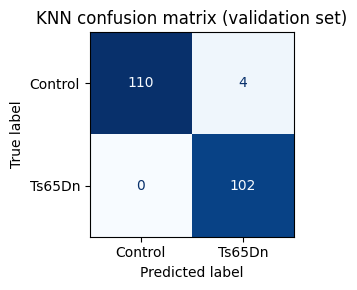

In [77]:
# building the model
knn = KNeighborsClassifier(
        n_neighbors=3
        
    )

# fitting the model on the scaled training set
knn.fit(X_train_sc, y_train)

# training performance
train_pred = knn.predict(X_train_sc)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print()

# Predictions on validation set
knn_y_pred = knn.predict(X_val_sc)

report = classification_metrics(y_val, knn_y_pred)
print("=== KNN ===")
print()
print("The accuracy on the validation set:",report["accuracy"])
print()
print("The F1 score on the validation set:",report["F1"])
print()
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, knn_y_pred,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("KNN confusion matrix (validation set)")
plt.tight_layout()
plt.show()

The overall accuracy and F1 score increased relative to the previous models, with a flawless classification of the normal samples into their correct class.

### Summary table of performances

In [78]:
# get the accuracy scores
baseline_train_acc = dummy.score(X_train_sc, y_train)
baseline_val_acc = dummy.score(X_val_sc, y_val)

log_train_acc = log_reg.score(X_train_sc, y_train)
log_val_acc = log_reg.score(X_val_sc, y_val)

knn_train_acc = knn.score(X_train_sc, y_train)
knn_val_acc = knn.score(X_val_sc, y_val)

rf_train_acc = rf.score(X_train, y_train)
rf_val_acc = rf.score(X_val, y_val)

# group them in a dataframe
summary = pd.DataFrame({
    "Model": ["Dummy", "Logistic Regression", "Random Forest", "KNN"],
    "Train Accuracy": [baseline_train_acc, log_train_acc, rf_train_acc, knn_train_acc],
    "Validation Accuracy": [baseline_val_acc, log_val_acc, rf_val_acc, knn_val_acc]
})

summary

,Model,Train Accuracy,Validation Accuracy
0,Dummy,0.527778,0.527778
1,Logistic Regression,0.970679,0.962963
2,Random Forest,1.000000,0.972222
3,KNN,0.996914,0.981481


The best-performing model happens to be the least interpretable model in this case since it does not produce anything tangible to work with, like coefficient scores and the most significant proteins in generating a signal.<br>
It just tells us that the samples seem to be clustered (stable neighborhoods) in the feature space, which further means that similar protein-expression profiles tend to correspond to the same biological condition.

It allows the researcher to infer a global overview on the nature of the data, without being too informative on the details driving this data organization.

## Section 11 — Diagnostic plots and learning curves

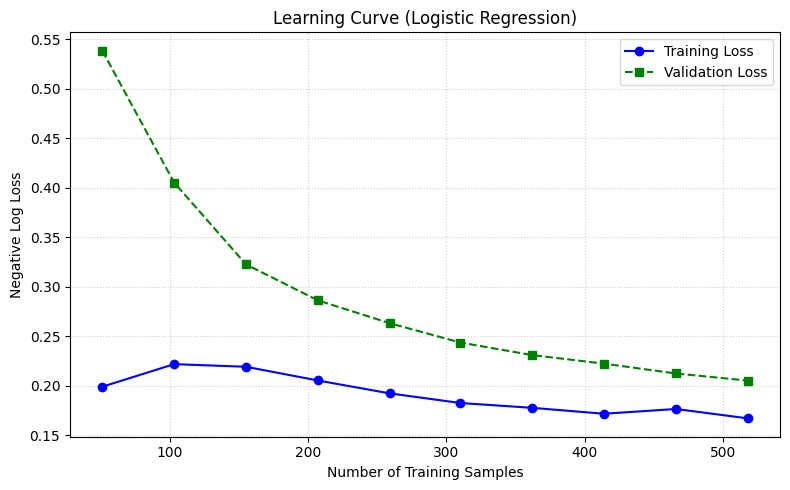

In [79]:
# Logistic Regression

from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    estimator=log_reg,
    X=X_train_sc, 
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, color="blue", marker="o", label="Training Loss")

plt.plot(train_sizes, val_mean, color="green", marker="s", linestyle="--", label="Validation Loss")

plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Negative Log Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

The learning curve was illustrated for loss against the number of samples.
To calculate the loss, the Cross-Entropy Function (Log Loss) was used since it is an acceptable method for binary classification purposes:
$$\text{LogLoss} = - \left( y \log(h(x)) + (1 - y) \log(1 - h(x)) \right)$$


The learning curve for logistic regression indicated there was no extreme loss across different sample sizes. Furthermore, after taking a sufficient number of samples, the difference between the training and validation loss became negligible. This means that not only did the model not suffer from high bias, but also the variance was quite balanced. On top of that, the model performance became even more satisfactory after the sample size reached 200. In general, the model showed robustness without any underfitting or overfitting.

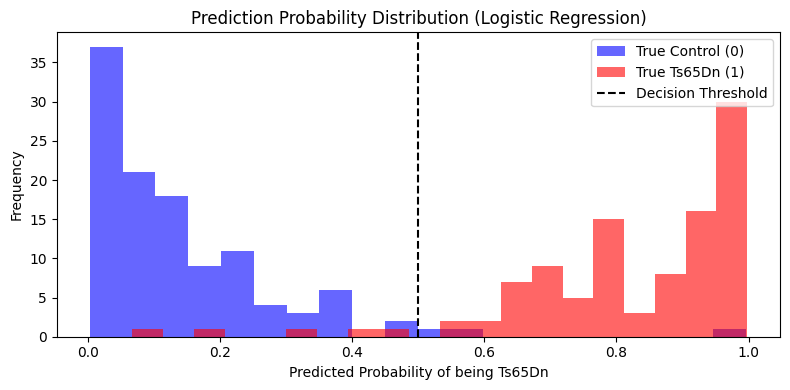

In [80]:
y_val_proba_log = log_reg.predict_proba(X_val_sc)[:, 1]

plt.figure(figsize=(8, 4))
plt.hist(y_val_proba_log[y_val == 0], bins=20, alpha=0.6, label="True Control (0)", color="blue")
plt.hist(y_val_proba_log[y_val == 1], bins=20, alpha=0.6, label="True Ts65Dn (1)", color="red")
plt.axvline(0.5, color='k', linestyle='--', label="Decision Threshold")
plt.title("Prediction Probability Distribution (Logistic Regression)")
plt.xlabel("Predicted Probability of being Ts65Dn")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

The associated probability distribution is U-shaped, which means that the model was mostly successful in classifying the samples correctly. Nevertheless, there were a few misclassifications that could be identified by both this plot and the confusion plot. Notably, the number of Ts65Dn samples that were classified as Control (False negative) is more than the number of Control samples that were classified as Ts65Dn (False positive).

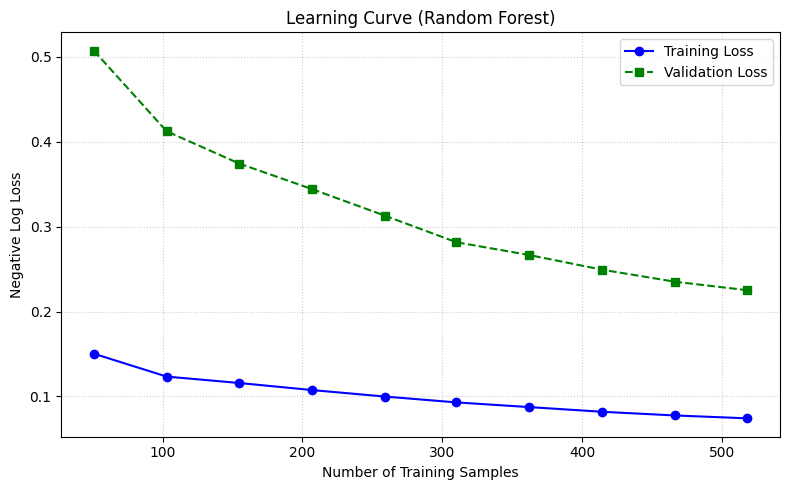

In [81]:
# Random Forest

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf,
    X=X_train, 
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, color="blue", marker="o", label="Training Loss")

plt.plot(train_sizes, val_mean, color="green", marker="s", linestyle="--", label="Validation Loss")

plt.title("Learning Curve (Random Forest)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Negative Log Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

Even though the random forest indicated a high accuracy in the validation set, the learning plot showed a huge gap between the training and validation sets. This slight inconsistency between accuracy and loss is due to the nature of the random forest. For instance, if 51% of the trees in the forest predict the class correctly, the prediction for that example has 100% accuracy, though there is a loss between 1 and 0.51. The gap also can mean that the fitted model has a high variance, which can lead to overfitting.

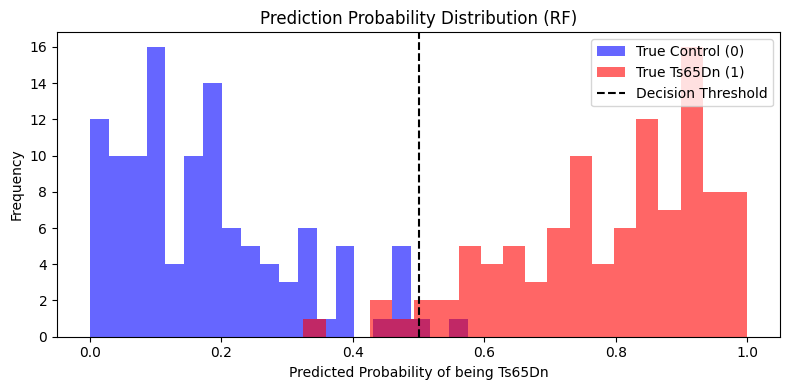

In [82]:

X_val_df = pd.DataFrame(X_val, columns=X_train.columns)
y_val_proba_rf = rf.predict_proba(X_val_df)[:, 1]

plt.figure(figsize=(8, 4))
plt.hist(y_val_proba_rf[y_val == 0], bins=20, alpha=0.6, label="True Control (0)", color="blue")
plt.hist(y_val_proba_rf[y_val == 1], bins=20, alpha=0.6, label="True Ts65Dn (1)", color="red")
plt.axvline(0.5, color='k', linestyle='--', label="Decision Threshold")
plt.title("Prediction Probability Distribution (RF)")
plt.xlabel("Predicted Probability of being Ts65Dn")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

The prediction probability distribution of the random forest suggests that the decision trees sometimes disagreed with each other. On top of that, the model suffered from poor confidence, and the probabilities for most of the samples were not near 0 and 1. Subsequently, the plot validates our claim on the instability of the model for binary classification. In conclusion, although the random forest approach was accurate on the given data, it was not sufficiently stable and may be inefficient when the signal is borderline.
Notably, in this kind of model, the validation set is usually more informative since the model has technically memorized the training set in a non-parametric way. 
Regarding the results, the random forest model required further optimization of the hyperparameters `n_estimators` and `depth`. However, we tried several values for the hyperparameters, but none of the combinations had a significant impact, so we just excluded RF from the suggested models.






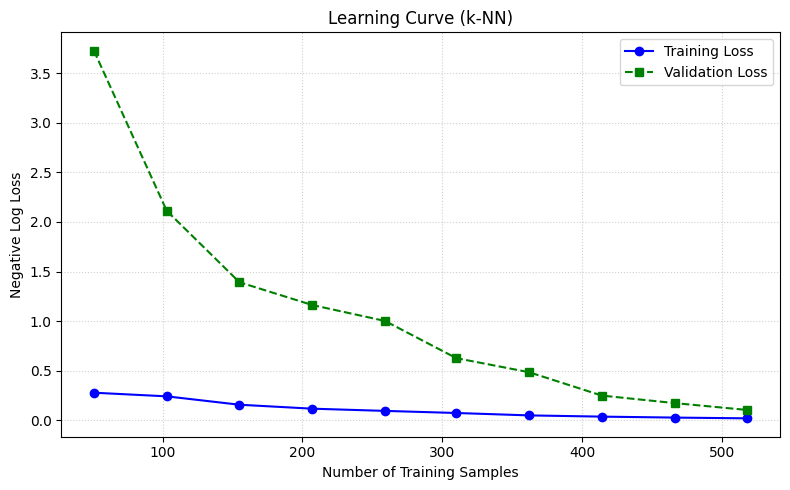

In [83]:
# KNN

train_sizes, train_scores, val_scores = learning_curve(
    estimator=knn,
    X=X_train_sc, 
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, color="blue", marker="o", label="Training Loss")

plt.plot(train_sizes, val_mean, color="green", marker="s", linestyle="--", label="Validation Loss")

plt.title("Learning Curve (k-NN)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Negative Log Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

The k-nearest neighbors model acquired the highest accuracy among all three models. Nonetheless, the learning curve revealed that when the sample size is less than 300, the value of log loss was approximately more than 0.7, which is more than a loss of a model with 50% probability of correct classification:

$$\text{Log Loss} = -[0 \cdot \log(0.5) + 1 \cdot \log(0.5)] = -\log(0.5) \approx 0.693$$

 In other words, using this model is worse than flipping a coin when we don't have enough sample size (>300). In contrast, when the sample size was quite large (>500), the value of log loss was around 0.1, which is low enough for an efficient model. Accordingly, we optimized our model to decrease the loss. We noticed there was a trade-off between accuracy and loss; to balance that, we chose k to be 5.

Training Accuracy: 0.9938271604938271

=== KNN ===

The accuracy on the validation set: 0.9675925925925926

The F1 score on the validation set: 0.9658536585365853



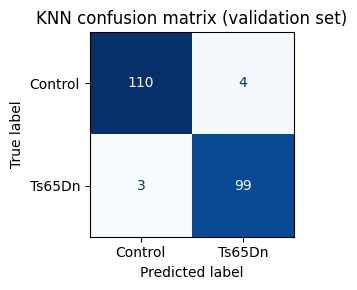

In [84]:
# Optimizing the k-NN model
knn = KNeighborsClassifier(
        n_neighbors=5
        
    )

# fitting the model on the scaled training set
knn.fit(X_train_sc, y_train)

# training performance
train_pred = knn.predict(X_train_sc)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print()

# Predictions on validation set
knn_y_pred = knn.predict(X_val_sc)

report = classification_metrics(y_val, knn_y_pred)
print("=== KNN ===")
print()
print("The accuracy on the validation set:",report["accuracy"])
print()
print("The F1 score on the validation set:",report["F1"])
print()
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, knn_y_pred,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("KNN confusion matrix (validation set)")
plt.tight_layout()
plt.show()

As it was expected, the model accuracy on the validation set decreased slightly.

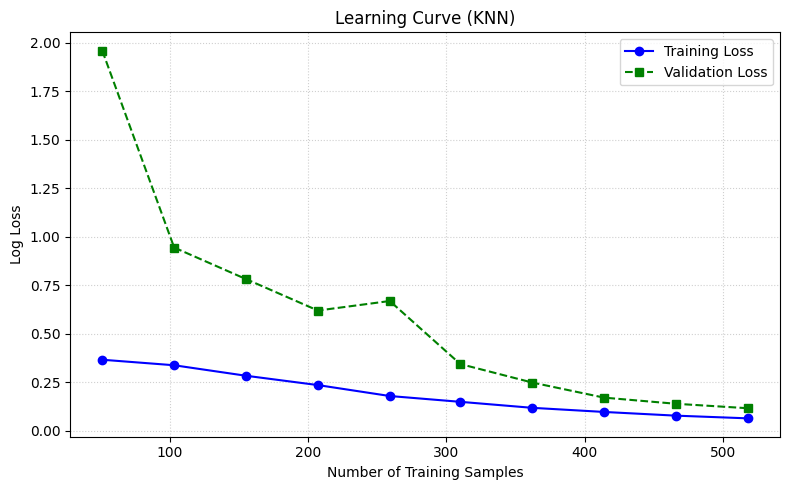

In [85]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=knn,
    X=X_train_sc, 
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, color="blue", marker="o", label="Training Loss")

plt.plot(train_sizes, val_mean, color="green", marker="s", linestyle="--", label="Validation Loss")

plt.title("Learning Curve (KNN)")
plt.xlabel("Number of Training Samples")
plt.ylabel("Log Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

As it is visible, after changing the hyperparameter k, the loss decreased dramatically across different sample sizes. Nevertheless, the model is still not as efficient as logistic regression for smaller sample sizes.

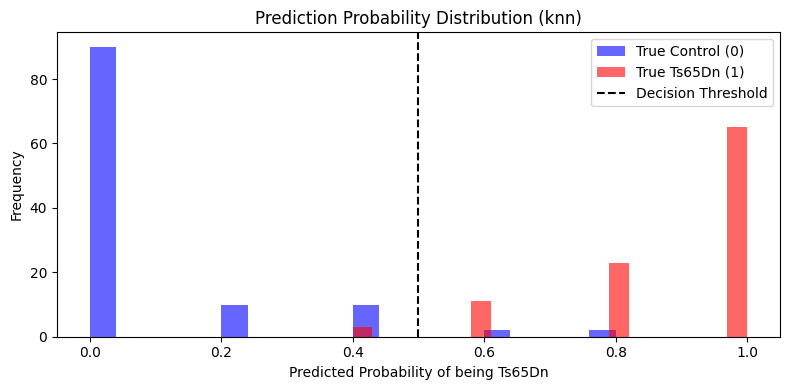

In [86]:
y_val_proba_knn = knn.predict_proba(X_val_sc)[:, 1]

plt.figure(figsize=(8, 4))
plt.hist(y_val_proba_knn[y_val == 0], bins=20, alpha=0.6, label="True Control (0)", color="blue")
plt.hist(y_val_proba_knn[y_val == 1], bins=20, alpha=0.6, label="True Ts65Dn (1)", color="red")
plt.axvline(0.5, color='k', linestyle='--', label="Decision Threshold")
plt.title("Prediction Probability Distribution (knn)")
plt.xlabel("Predicted Probability of being Ts65Dn")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

When k was assigned to be 5, we got 6 different possible probabilities for each sample, i.e., 0, 1/5, 2/5, 3/5, 4/5, and 1. Thus, the probability plot appeared to be discrete. In general, most of the values were near 1 and 0, which means the model predicted most of the samples with high confidence.



## Section 12 — Final model selection

Finally, the logistic regression was selected as the primary model for the binary classification of Ts65Dn and Control samples. The model performed very well in terms of accuracy in both the training and validation sets. Subsequently, the numbers of false positives and false negatives were not high, unlike the baseline model that had only a ~53% accuracy. According to the associated learning curve, the model had a balanced bias-variance tradeoff and did not indicate any severe overfitting or underfitting. The U-shaped probability distribution also revealed that the logistic model had a high confidence in the predictions. Besides the accuracy and robustness, the main reason that we chose logistic regression as our predictive model was the biological interpretability. Since the logistic regression is parametric and uses a sigmoid function, it enables us to measure the impact of each feature quantitatively.

On the other hand, the non-parametric methods like k-NN and random forest didn't provide the biological interpretability that the logistic regression provided. In addition, k-NN was not suitable for sample sizes lower than ~350 even after optimization, though the probability distribution indicated high confidence in predictions. Regarding the random forest model, although it showed low losses even for the small sample sizes, its instability made it as a less reasonable option to predict the biological labels.

The main limitation of logistic regression is that it misses the non-linear relationship between the features. In that case, using k-NN could be a fine approach to investigate the clusters and the non-parametric relations.

## Section 13 — Final test evaluation


=== Final Test Evaluation ===

The accuracy on the test set: 0.9814814814814815

The F1 score on the test set: 0.98



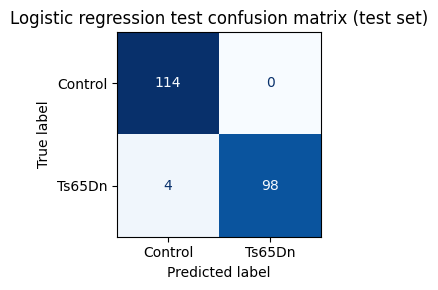

In [87]:
y_test_pred = log_reg.predict(X_test_sc)

report = classification_metrics(y_test, y_test_pred)
print("=== Final Test Evaluation ===")
print()
print("The accuracy on the test set:",report["accuracy"])
print()
print("The F1 score on the test set:",report["F1"])
print()
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Logistic regression test confusion matrix (test set)")
plt.tight_layout()
plt.show()

The results demonstrated that the model performed effectively on the test set, achieving an accuracy of ~0.982 and an F1 score of ~0.980. Among the 216 samples in the set, only 4 of them were misclassified and produced false-negative results. Notably, the accuracy scores for the training and validation sets were 0.971 and 0.963, respectively. Basically, the model was slightly more accurate at classifying samples in the test set than in the validation or training sets. One reason for this superior performance might be that we used the L2 penalty to prevent the model from memorizing the training set. However, seemingly adding this bias led to a better generalization of the model. Overall, the model proved to be highly stable, robust, and generalizable, so it can be used to draw a biological conclusion.

## Section 14 — Biological interpretation

To find the impactful biological patterns, we extracted the most influencial coefficients to see which proteins were more effective in the classification procedure.

In [88]:
# Extracting the raw coeficients
coefficients = log_reg.coef_[0]

# Calculating the Odds Ratio
odds_ratios = np.exp(coefficients)

# Generating the dataframe
impact = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient (Beta)': coefficients,
    'Odds Ratio (e^Beta)': odds_ratios
})

# Sorting by the absolute value of beta
impact['Abs_Beta'] = impact['Coefficient (Beta)'].abs()
impact = impact.sort_values(by='Abs_Beta', ascending=False).drop(columns=['Abs_Beta'])

# Viewing the top 10 most influential biomarkers
print(impact.head(10))

    Feature  Coefficient (Beta)  Odds Ratio (e^Beta)
30    APP_N            1.826000             6.209003
41  TIAM1_N            0.774786             2.170127
28   TRKA_N            0.709742             2.033467
72    SYP_N           -0.593340             0.552479
24    ERK_N           -0.530274             0.588444
1   ITSN1_N            0.509101             1.663795
58  GluR3_N           -0.457730             0.632718
37  AMPKA_N           -0.454211             0.634949
23    ELK_N           -0.449015             0.638257
33   MTOR_N           -0.430275             0.650330


The most remarkable biological result belonged to the APP protein, which appeared in the first row with by far the highest coefficient. The odds ratio for this biomarker was estimated at ~6.21, meaning that if the expression of this protein increases by one standard deviation, the model is approximately 6.21 times more likely to classify the sample as Ts65Dn (Down Syndrome). This result is totally biologically plausible since the gene for Amyloid Precursor Protein (APP) is on chromosome 21, which the patient has an extra copy of (Elangovan et al., 2023). This reveals that the model was strong enough to identify the importance of this protein. The gene for the second impactful protein, T-cell lymphoma invasion and metastasis-inducing protein 1 (TIAM1), is on chromosome 21 (Ives et al., 1998).

Among the effective proteins with negative coefficients, synaptophysin (SYP) has the greatest absolute value. According to the odds ratio, for a one-unit increase in the expression, there is ~45% less chance that the sample is diagnosed with Down Syndrome (Ts65Dn). This is also a reasonable and plausible result because this protein is underexpressed in patients with Down Syndrome, especially in older individuals (Downes et al., 2008). 

Although we can claim our model was able to classify patients with a trisomy of chromosome 21 in this specific dataset, it has some limitations that may fail the global generalization. First of all, the model just considers correlation, not the actual causality. As an example, Amyloid Precursor Protein is over-expressed in other conditions, such as Alzheimer's (Carlson et al., 1997) and iron (Fe^2+^) overload (Khan, 2025). Therefore, there might be confounding factors that alter our results. Another drawback is that the model does not account for interactions among biological elements. For instance, the expression and regulation of the genes, and subsequently the proteins, can be dependent on each other due to the associated pathways, protein-protein interactions (PPI), inhibitors, and activators. The last challenge is that, unlike RF or kNN, the logistic regression model is parametric, which prevents it from capturing non-parametric relationships. Therefore, further analysis is required to uncover the dataset's secrets and build a perfect classification model. In addition to wet-lab analyses (such as immunoblotting, microscopy, and tracking), various computational proteomic approaches can be used. Quantitative tools like MaxQuant, Bioconductor (R), Gene Set Enrichment Analysis (GSEA), Enrichr, and several other software tools are widely used for protein expression and enrichment analyses, which can be applied to our study to improve our model. 

## Section 15 — References

Higuera, C., Gardiner, K. J., & Cios, K. J. (2015). Self-Organizing Feature Maps Identify Proteins Critical to Learning in a Mouse Model of Down Syndrome. PloS one, 10(6), e0129126. https://doi.org/10.1371/journal.pone.0129126

Elangovan, A., Babu, H. W. S., Iyer, M., Gopalakrishnan, A. V., & Vellingiri, B. (2023). Untangle the mystery behind DS-associated AD - Is APP the main protagonist?. Ageing research reviews, 87, 101930. https://doi.org/10.1016/j.arr.2023.101930

Ives, J. H., Dagna-Bricarelli, F., Basso, G., Antonarakis, S. E., Jee, R., Cotter, F., & Nizetić, D. (1998). Increased levels of a chromosome 21-encoded tumour invasion and metastasis factor (TIAM1) mRNA in bone marrow of Down syndrome children during the acute phase of AML(M7). Genes, chromosomes & cancer, 23(1), 61–66.

Downes, E.C., Robson, J., Grailly, E., Abdel-All, Z., Xuereb, J., Brayne, C., Holland, A., Honer, W.G. and Mukaetova-Ladinska, E.B. (2008), Loss of synaptophysin and synaptosomal-associated protein 25-kDa (SNAP-25) in elderly Down syndrome individuals. Neuropathology and Applied Neurobiology, 34: 12-22. https://doi.org/10.1111/j.1365-2990.2007.00899.x

Carlson, G. A., Borchelt, D. R., Dake, A., Turner, S., Danielson, V., Coffin, J. D., Eckman, C., Meiners, J., Nilsen, S. P., Younkin, S. G., & Hsiao, K. K. (1997). Genetic modification of the phenotypes produced by amyloid precursor protein overexpression in transgenic mice. Human molecular genetics, 6(11), 1951–1959. https://doi.org/10.1093/hmg/6.11.1951

Khan M. A. (2025). Iron-Mediated Overexpression of Amyloid Precursor Protein via Iron Responsive mRNA in Alzheimer's Disease. International journal of molecular sciences, 26(11), 5283. https://doi.org/10.3390/ijms26115283